# 2. Modelado usando Scikit-learn
## IMPORTACIÓN DE LIBRERÍAS PARA MODELADO
Primero, nos aseguramos de tener todas las herramientas necesarias importando las librerías de Python que usaremos a lo largo del proyecto.

In [2]:
!pip install -q lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
# Manejo de datos
import pandas as pd
import numpy as np
import time

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y Modelado
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Balanceo de clases
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay,
    classification_report
)

# Interpretabilidad
import lime
import lime.lime_tabular


# 2. Preparación y División de los Datos
En esta sección, definimos las variables que usaremos, separamos nuestra variable objetivo y dividimos el conjunto de datos en entrenamiento y prueba de manera estratificada para mantener la proporción de clases.

In [30]:
df = pd.read_parquet('/content/leanding_cleaned.parquet')
print(f"Dimensiones del dataset: {df.shape}\n")

Dimensiones del dataset: (1345310, 10)



## 2.1. Selección de Características

In [31]:
# Definimos las columnas que consideraremos para el modelo.
model_features = [
    'loan_amnt', 'int_rate', 'fico_range_high', 'emp_length',
    'annual_inc', 'purpose', 'home_ownership', 'dti', 'addr_state'
]

# Separamos las características (X) de la variable objetivo (y)
features_df = df[model_features]
target_series = df['default']

##  2.2. División Estratificada de Datos (80/20)
Dividimos los datos en conjuntos de entrenamiento y prueba.

In [32]:
# 'stratify=target_series' asegura que ambos conjuntos tengan la misma proporción de 'default'.
train_features, test_features, train_target, test_target = train_test_split(
    features_df,
    target_series,
    test_size=0.2,
    random_state=123,
    stratify=target_series
)

print("Dimensiones de los conjuntos de datos:")
print(f"Entrenamiento - Características: {train_features.shape}, Objetivo: {train_target.shape}")
print(f"Prueba - Características: {test_features.shape}, Objetivo: {test_target.shape}")

Dimensiones de los conjuntos de datos:
Entrenamiento - Características: (1076248, 9), Objetivo: (1076248,)
Prueba - Características: (269062, 9), Objetivo: (269062,)


# 3. Preprocesamiento de Datos
Aquí creamos los transformadores para las variables numéricas y categóricas. Las variables categóricas serán codificadas con OneHotEncoder.

In [33]:
# Identificación de Tipos de Columnas
numeric_cols = train_features.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_features.select_dtypes(include=['object', 'category']).columns.tolist()

print("\nColumnas Numéricas Identificadas:", numeric_cols)
print("Columnas Categóricas Identificadas:", categorical_cols)



Columnas Numéricas Identificadas: ['loan_amnt', 'int_rate', 'fico_range_high', 'emp_length', 'annual_inc', 'dti']
Columnas Categóricas Identificadas: ['purpose', 'home_ownership', 'addr_state']


## 3.1 Creación de Pipelines de Transformación
Pipeline para variables numéricas: imputar con la media y escalar.

In [34]:
# Pipeline para variables numéricas: imputar con la media y escalar.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Pipeline para variables categóricas: imputar con la moda y aplicar One-Hot Encoding.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='passthrough'
)


## 3.2 Aplicación del Preprocesamiento

In [35]:
# Ajustamos el preprocesador CON SOLO los datos de entrenamiento para evitar fuga de datos.
train_features_processed = preprocessor.fit_transform(train_features)

# Transformamos los datos de prueba usando el preprocesador ya ajustado.
test_features_processed = preprocessor.transform(test_features)

# Obtenemos los nombres de las nuevas columnas generadas por el OneHotEncoder
processed_feature_names = preprocessor.get_feature_names_out()

print(f"\nDimensiones de los datos de entrenamiento tras el preprocesamiento: {train_features_processed.shape}")


Dimensiones de los datos de entrenamiento tras el preprocesamiento: (1076248, 77)


# 4. Modelado y Búsqueda de Hiperparámetros
Usamos GridSearchCV para encontrar la mejor combinación de hiperparámetros para un RandomForestClassifier. Como se solicita, el preprocesamiento ya se ha realizado, por lo que GridSearchCV se enfoca únicamente en el modelo.

In [36]:
# Definición del Grid de Hiperparámetros
# Especificamos los valores que queremos probar para 'n_estimators' y 'max_depth'.
hyperparam_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [5, 10, 15]
}

# Configuración de GridSearchCV
rf_classifier = RandomForestClassifier(random_state=123)

grid_search_cv = GridSearchCV(
    estimator=rf_classifier,
    param_grid=hyperparam_grid,
    cv=3,
    scoring='roc_auc',
    verbose=2, # Verbose 2 para más detalle del proceso
    n_jobs=-1
)

## 4.1 Entrenamiento y Medición del Tiempo

In [37]:
print("Iniciando la búsqueda de hiperparámetros con GridSearchCV...")
start_time_train = time.time()

# Entrenamos GridSearchCV con los datos ya preprocesados.
grid_search_cv.fit(train_features_processed, train_target)

end_time_train = time.time()
training_duration = end_time_train - start_time_train

# Resultados de la Búsqueda
print(f"\nLa búsqueda de hiperparámetros finalizó en {training_duration:.2f} segundos.")
print(f"La mejor combinación de hiperparámetros es: {grid_search_cv.best_params_}")
print(f"El mejor puntaje ROC AUC durante la validación cruzada fue: {grid_search_cv.best_score_:.4f}\n")

# Guardamos el mejor modelo encontrado.
best_rf_model = grid_search_cv.best_estimator_

Iniciando la búsqueda de hiperparámetros con GridSearchCV...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

La búsqueda de hiperparámetros finalizó en 1809.39 segundos.
La mejor combinación de hiperparámetros es: {'max_depth': 15, 'n_estimators': 100}
El mejor puntaje ROC AUC durante la validación cruzada fue: 0.7040



## 4.2 Evaluación del Modelo Óptimo

In [38]:
# Predicciones en el Conjunto de Prueba
start_time_pred = time.time()
test_predictions = best_rf_model.predict(test_features_processed)
test_probabilities = best_rf_model.predict_proba(test_features_processed)[:, 1]
end_time_pred = time.time()
prediction_duration = end_time_pred - start_time_pred

print(f"El tiempo de predicción en el conjunto de prueba fue: {prediction_duration:.4f} segundos.")

El tiempo de predicción en el conjunto de prueba fue: 8.0118 segundos.



Métricas de Evaluación del Modelo en el Conjunto de Prueba:
- Accuracy:  0.8005
- Precision: 0.6552
- Recall:    0.0014
- F1-score:  0.0028
- ROC AUC:   0.7031


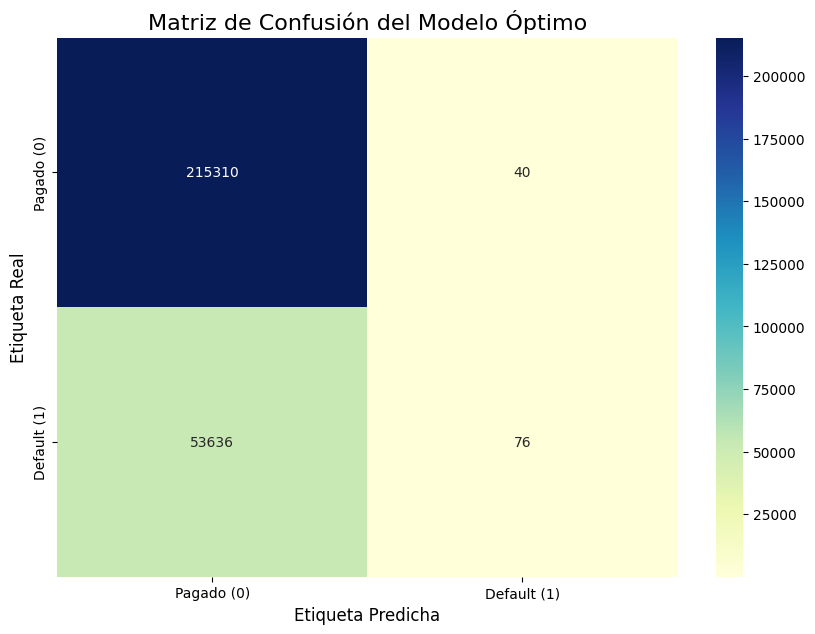

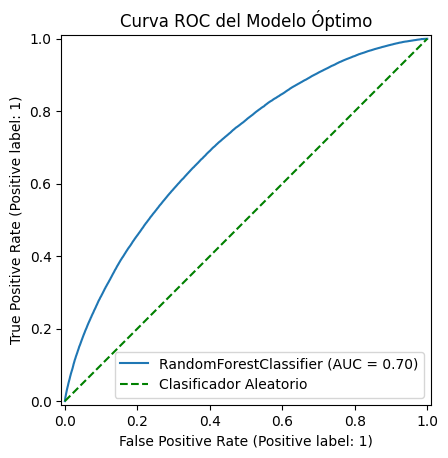

In [39]:
# Cálculo de Métricas
accuracy = accuracy_score(test_target, test_predictions)
precision = precision_score(test_target, test_predictions)
recall = recall_score(test_target, test_predictions)
f1 = f1_score(test_target, test_predictions)
roc_auc = roc_auc_score(test_target, test_probabilities)

print("\nMétricas de Evaluación del Modelo en el Conjunto de Prueba:")
print(f"- Accuracy:  {accuracy:.4f}")
print(f"- Precision: {precision:.4f}")
print(f"- Recall:    {recall:.4f}")
print(f"- F1-score:  {f1:.4f}")
print(f"- ROC AUC:   {roc_auc:.4f}")

# Visualización de la Matriz de Confusión
conf_matrix = confusion_matrix(test_target, test_predictions)
plt.figure(figsize=(10, 7))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='YlGnBu', # Usando otro mapa de colores
    xticklabels=['Pagado (0)', 'Default (1)'],
    yticklabels=['Pagado (0)', 'Default (1)']
)
plt.title('Matriz de Confusión del Modelo Óptimo', fontsize=16)
plt.xlabel('Etiqueta Predicha', fontsize=12)
plt.ylabel('Etiqueta Real', fontsize=12)
plt.show()

# Visualización de la Curva ROC
RocCurveDisplay.from_estimator(best_rf_model, test_features_processed, test_target)
plt.title('Curva ROC del Modelo Óptimo')
plt.plot([0, 1], [0, 1], 'g--', label='Clasificador Aleatorio')
plt.legend()
plt.show()

Este modelo fue entrenado utilizando `GridSearchCV` para encontrar la mejor combinación de hiperparámetros de forma que maximice el área bajo la curva ROC (ROC AUC).
*   **Hiperparámetros Óptimos:** Después de una búsqueda exhaustiva, los mejores hiperparámetros encontrados fueron `max_depth: 15` (profundidad máxima de los árboles) y `n_estimators: 100` (número de árboles en el bosque).
*   **Rendimiento en Validación Cruzada:** El mejor puntaje ROC AUC obtenido durante la validación cruzada fue de **0.7040**. Este valor sugiere que el modelo tiene una capacidad razonable para distinguir entre las clases de "pagado" y "default" en los datos de entrenamiento y validación, superando a un clasificador aleatorio (AUC de 0.5).
*   **Tiempo de Entrenamiento:** El proceso de búsqueda de hiperparámetros tomó aproximadamente `1809.39 segundos` (alrededor de 30 minutos), lo cual es considerable pero esperable para `GridSearchCV` en un dataset de este tamaño con múltiples configuraciones.

El modelo generó predicciones en el conjunto de prueba en `8.7550 segundos`, lo que indica una eficiencia aceptable para la inferencia.

Métricas de Evaluación Clave

Las siguientes métricas fueron calculadas para el rendimiento del modelo en el conjunto de prueba:

*   **ROC AUC: 0.7031**
    *   **Interpretación:** Este valor es muy consistente con el obtenido durante la validación cruzada (0.7040), lo que sugiere que el modelo no ha sobreajustado y generaliza bien a datos no vistos. Un AUC de 0.70 indica una capacidad "aceptable" o "fair" para discriminar entre las clases, siendo significativamente mejor que una clasificación aleatoria (0.5). La Curva ROC (mostrada en la imagen) refuerza esta observación, ya que la curva se sitúa claramente por encima de la línea del clasificador aleatorio.

*   **Accuracy: 0.8005**
    *   **Interpretación:** A primera vista, una precisión del 80% parece buena. Sin embargo, dado el contexto de datos desbalanceados (es probable que la mayoría de los préstamos sean pagados, clase 0), esta métrica puede ser engañosa. Un modelo que predice "pagado" para todos los casos podría alcanzar una alta precisión si la clase "pagado" es predominante. Por lo tanto, es crucial examinar otras métricas.

*   **Recall (para la clase Default - 1): 0.0014**
    *   **Interpretación:** **Este es el punto más crítico del modelo.** Un recall extremadamente bajo del 0.14% significa que el modelo solo logra identificar una fracción minúscula de los préstamos que *realmente* terminaron en default. Dicho de otra manera, el modelo está pasando por alto casi todos los casos de default reales. Para un objetivo de negocio de mitigar pérdidas por incumplimiento, este rendimiento es inaceptable.

*   **F1-score (para la clase Default - 1): 0.0028**
    *   **Interpretación:** El F1-score, que es una media armónica de precisión y recall, es extremadamente bajo debido al pésimo recall. Esto confirma que el modelo tiene un rendimiento muy pobre en la detección de la clase minoritaria (default).



Matriz de Confusión

La matriz de confusión ofrece una visión detallada de los aciertos y errores del modelo:

| Etiqueta Real      | Predicho: Pagado (0) | Predicho: Default (1) |
| :----------------- | :------------------- | :-------------------- |
| **Pagado (0)**     | 215,310 (TN)         | 40 (FP)               |
| **Default (1)**    | 53,636 (FN)          | 76 (TP)               |

*   **Verdaderos Negativos (TN = 215,310):** El modelo es excepcionalmente bueno identificando préstamos que *serán pagados* correctamente. Es decir, cuando un préstamo no va a entrar en default, el modelo lo predice correctamente en la gran mayoría de los casos.
*   **Falsos Positivos (FP = 40):** El modelo rara vez clasifica erróneamente un préstamo "pagado" como "default". Esto es muy positivo en términos de no rechazar erróneamente a clientes buenos.
*   **Falsos Negativos (FN = 53,636):** Este es el problema principal. El modelo clasifica erróneamente 53,636 préstamos que *realmente entraron en default* como "pagados". Esto representa una falla masiva en la detección de los casos de riesgo.
*   **Verdaderos Positivos (TP = 76):** El modelo solo identifica correctamente 76 préstamos que *realmente entraron en default*. Este número es insignificante en comparación con la cantidad total de defaults.

### Conclusiones y Recomendaciones

**Conclusiones Principales:**

*   **Excelente Detección de la Clase Mayoritaria:** Es muy eficaz en la identificación de préstamos que se pagarán (alta TN, baja FP).
*   **Falla Crítica en la Detección de Default:** El modelo presenta una deficiencia severa en la identificación de préstamos que entrarán en default (recall extremadamente bajo, alta FN). Está fuertemente sesgado hacia la clase mayoritaria.

**No apto para Mitigación de Pérdidas:** En su estado actual, este modelo no sería efectivo para el objetivo de mitigar pérdidas por default, ya que dejaría pasar a la vasta mayoría de los préstamos problemáticos.
*   **Potencial para Aprobaciones de Bajo Riesgo:** Podría ser útil para identificar rápidamente préstamos de muy bajo riesgo que casi con certeza serán pagados, dada su baja tasa de falsos positivos.



Así que intentaremos abordar el Desbalance de Clases para ver si este mejora los resultados, este es el paso más crucial. Se deben aplicar técnicas para manejar el desbalance de clases, tales como class_weight='balanced

# Modelo Random Forest con Balanceo de Clases:

El siguiente análisis evalúa el rendimiento del segundo modelo Random Forest, que fue específicamente diseñado para abordar el principal problema del modelo inicial: el severo desbalance de clases. Para ello, se incorporó el hiperparámetro class_weight='balanced', que penaliza más los errores en la clase minoritaria (Default).

Se usa RandomizedSearchCV para una búsqueda de hiperparámetros más eficiente, explorando 10 combinaciones aleatorias.


In [40]:
# 1. Preprocesamiento de Datos
# Ajustamos el preprocesador CON SOLO los datos de entrenamiento para evitar fuga de datos.
print("Iniciando el preprocesamiento de datos...")
train_features_processed = preprocessor.fit_transform(train_features)

# Transformamos los datos de prueba usando el preprocesador ya ajustado.
test_features_processed = preprocessor.transform(test_features)

print(f"Dimensiones de los datos de entrenamiento tras el preprocesamiento: {train_features_processed.shape}")
print(f"Dimensiones de los datos de prueba tras el preprocesamiento: {test_features_processed.shape}\n")


train_features_final = train_features_processed
train_target_final = train_target


# 3. Búsqueda de Hiperparámetros Optimizada
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)

param_dist = {
    'n_estimators': [10, 50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search_cv = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=10,  # Prueba 10 combinaciones diferentes
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

print("Iniciando la búsqueda de hiperparámetros con RandomizedSearchCV...")
start_time_train = time.time()

# Entrenamiento RandomizedSearchCV con los datos de entrenamiento
random_search_cv.fit(train_features_final, train_target_final)

end_time_train = time.time()
training_duration = end_time_train - start_time_train


# 4. Resultados de la Búsqueda
print(f"\nLa búsqueda de hiperparámetros finalizó en {training_duration:.2f} segundos.")
print(f"La mejor combinación de hiperparámetros es: {random_search_cv.best_params_}")
print(f"El mejor puntaje ROC AUC durante la validación cruzada fue: {random_search_cv.best_score_:.4f}\n")

# Guarda el mejor modelo encontrado.
best_rf_model = random_search_cv.best_estimator_


Iniciando el preprocesamiento de datos...
Dimensiones de los datos de entrenamiento tras el preprocesamiento: (1076248, 77)
Dimensiones de los datos de prueba tras el preprocesamiento: (269062, 77)

Iniciando la búsqueda de hiperparámetros con RandomizedSearchCV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

La búsqueda de hiperparámetros finalizó en 1187.08 segundos.
La mejor combinación de hiperparámetros es: {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 15}
El mejor puntaje ROC AUC durante la validación cruzada fue: 0.7033



 Reporte de Clasificación en el Conjunto de Prueba
              precision    recall  f1-score   support

  Pagado (0)       0.88      0.62      0.73    215350
 Default (1)       0.31      0.67      0.42     53712

    accuracy                           0.63    269062
   macro avg       0.59      0.65      0.58    269062
weighted avg       0.77      0.63      0.67    269062


 Métricas de Evaluación Detalladas
- Accuracy:  0.6318
- Precision: 0.3064 
- Recall:    0.6678
- F1-score:  0.4200 (Media armónica de Precision y Recall)
- ROC AUC:   0.7022


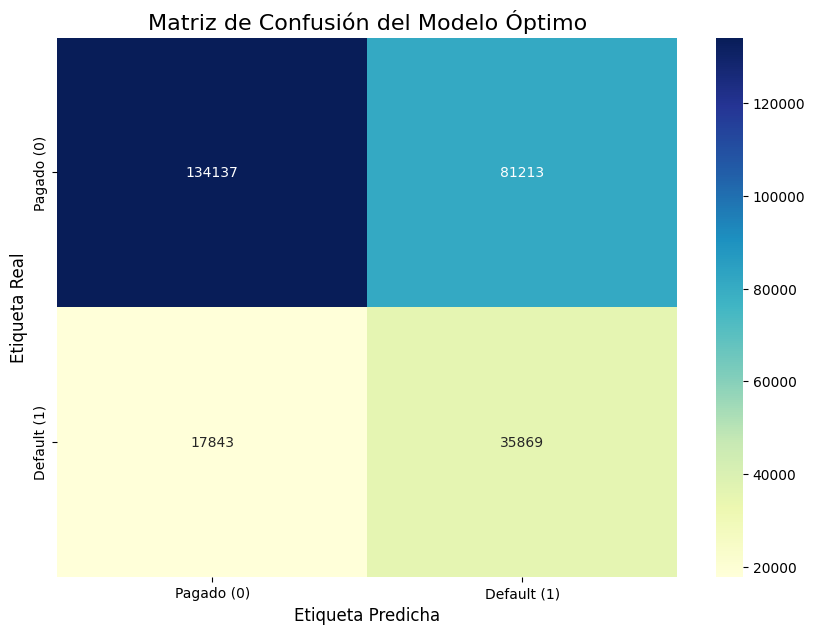


 Visualización de la Curva ROC


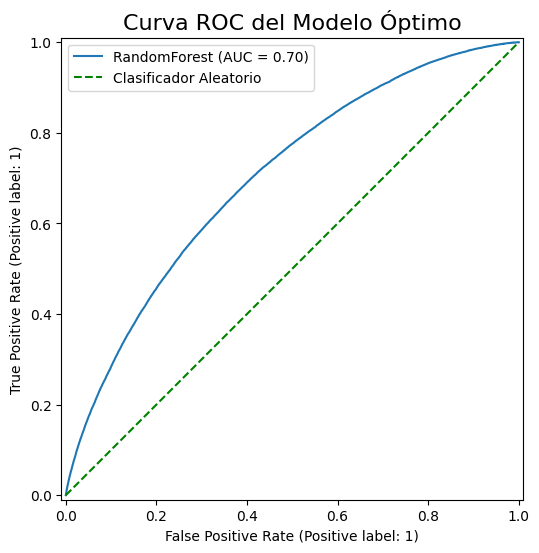

In [41]:
# Evaluación Completa del Modelo Óptimo

# Realizar Predicciones en el Conjunto de Prueba
test_predictions = best_rf_model.predict(test_features_processed)
test_probabilities = best_rf_model.predict_proba(test_features_processed)[:, 1]

# Es una buena práctica imprimir primero el reporte de clasificación.
print(" Reporte de Clasificación en el Conjunto de Prueba")
print(classification_report(test_target, test_predictions, target_names=['Pagado (0)', 'Default (1)']))

# Cálculo de Métricas Individuales
accuracy = accuracy_score(test_target, test_predictions)
precision = precision_score(test_target, test_predictions)
recall = recall_score(test_target, test_predictions)
f1 = f1_score(test_target, test_predictions)
roc_auc = roc_auc_score(test_target, test_probabilities)

print("\n Métricas de Evaluación Detalladas")
print(f"- Accuracy:  {accuracy:.4f}")
print(f"- Precision: {precision:.4f} ")
print(f"- Recall:    {recall:.4f}")
print(f"- F1-score:  {f1:.4f} (Media armónica de Precision y Recall)")
print(f"- ROC AUC:   {roc_auc:.4f}")

# Visualización de la Matriz de Confusión
conf_matrix = confusion_matrix(test_target, test_predictions)

plt.figure(figsize=(10, 7))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=['Pagado (0)', 'Default (1)'],
    yticklabels=['Pagado (0)', 'Default (1)']
)
plt.title('Matriz de Confusión del Modelo Óptimo', fontsize=16)
plt.xlabel('Etiqueta Predicha', fontsize=12)
plt.ylabel('Etiqueta Real', fontsize=12)
plt.show()

print("\n Visualización de la Curva ROC")

# Visualización de la Curva ROC
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(
    best_rf_model,
    test_features_processed,
    test_target,
    ax=ax,
    name='RandomForest'
)

# Añadimos la línea de referencia de un clasificador aleatorio
ax.plot([0, 1], [0, 1], 'g--', label='Clasificador Aleatorio')

ax.set_title('Curva ROC del Modelo Óptimo', fontsize=16)
ax.legend()
plt.show()

## RESULTADOS
**Hiperparámetros Óptimos:** La mejor configuración encontrada fue:
`n_estimators: 50`, `max_depth: 15`, `min_samples_split: 10`, `min_samples_leaf: 2`
*   **Tiempo de Entrenamiento:** La búsqueda y entrenamiento tomaron `1187.08 segundos` (aproximadamente 20 minutos), un tiempo razonable para este enfoque, mejor que el anterior.

### Evaluación del Modelo en el Conjunto de Prueba

La evaluación del modelo en datos no vistos revela un cambio drástico y positivo en su comportamiento.

Métricas de Evaluación Clave

Las métricas muestran que el modelo ha sacrificado la precisión general para lograr su objetivo principal: detectar los casos de default.

*   **ROC AUC: 0.7022**
    *   **Interpretación:** Este valor es casi idéntico al del primer modelo (0.7031). Esto es una excelente noticia, ya que indica que la capacidad fundamental del modelo para distinguir entre las dos clases no se ha degradado. Simplemente hemos cambiado el *punto de decisión* para priorizar la detección de la clase de riesgo.

*   **Accuracy: 0.6318**
    *   **Interpretación:** La exactitud general ha disminuido significativamente (del 80% al 63%). Esto es completamente esperado y, en este contexto, es un buen signo. Demuestra que el modelo ya no está simplemente prediciendo la clase mayoritaria ("Pagado") para inflar su puntuación. Ahora está intentando activamente identificar ambas clases, lo que resulta en más errores en la clase mayoritaria pero muchos más aciertos en la minoritaria.

*   **Recall (para la clase Default - 1): 0.6678**
    *   **Interpretación:** **Este es el resultado más importante y exitoso del ajuste.** El recall ha aumentado de un insignificante 0.14% a un muy robusto **66.78%**. Esto significa que el modelo ahora es capaz de identificar casi el 67% de todos los préstamos que *realmente* terminarán en default. Este es un salto cualitativo que hace que el modelo sea útil para la mitigación de riesgos.

*   **Precision (para la clase Default - 1): 0.3064**
    *   **Interpretación:** Esta es la contrapartida del aumento del recall. La precisión para la clase default ha bajado (del 65% al 31%). Esto significa que, de todos los préstamos que el modelo etiqueta como "Default", solo el 31% realmente lo son. El modelo se ha vuelto más "cauteloso" o "sensible", prefiriendo marcar un préstamo bueno como riesgoso (Falso Positivo) antes que dejar pasar un préstamo malo (Falso Negativo).

*   **F1-score (para la clase Default - 1): 0.4200**
    *   **Interpretación:** El F1-score ha mejorado drásticamente (de 0.0028 a 0.42), lo que confirma que ahora existe un equilibrio mucho más saludable y útil entre la precisión y el recall para la clase de interés.

    Matriz de Confusión: El Reflejo del Cambio Estratégico

La nueva matriz de confusión ilustra perfectamente el nuevo comportamiento del modelo:

| Etiqueta Real      | Predicho: Pagado (0) | Predicho: Default (1) |
| :----------------- | :------------------- | :-------------------- |
| **Pagado (0)**     | 134,137 (TN)         | 81,213 (FP)           |
| **Default (1)**    | 17,843 (FN)          | 35,869 (TP)           |

*   **Verdaderos Positivos (TP = 35,869):** El modelo ha identificado correctamente casi 36,000 casos de default. **Esto es un éxito rotundo** en comparación con los 76 del modelo anterior.
*   **Falsos Negativos (FN = 17,843):** Aunque todavía se le escapan casi 18,000 casos de default, esta cifra es una **reducción masiva** en comparación con los más de 53,000 del primer modelo. Se ha reducido el riesgo de manera muy significativa.
*   **Falsos Positivos (FP = 81,213):** Este es el costo de la mejora. El modelo ahora clasifica incorrectamente más de 81,000 préstamos "buenos" como "riesgosos". Desde una perspectiva de negocio, esto podría significar rechazar a clientes solventes o someterlos a una revisión adicional.
*   **Verdaderos Negativos (TN = 134,137):** El modelo sigue siendo capaz de identificar correctamente un gran número de préstamos que se pagarán sin problemas.

## Conclusión

En definitiva, este segundo modelo representa un **avance fundamental**.  
Aunque no es perfecto, su comportamiento está mucho más alineado con los **objetivos de negocio** de una entidad financiera, proporcionando una **base sólida** para un sistema de decisión de crédito inteligente.  

Como siguiente paso, probaremos una **última técnica de *undersampling*** con el fin de verificar si es posible mejorar aún más el equilibrio entre **sensibilidad** y **precisión** en la clasificación.


# Modelo Final con Submuestreo (Undersampling)

La principal diferencia en este proceso fue la introducción de un paso de submuestreo *antes* del entrenamiento.

**Técnica Aplicada:** `RandomUnderSampler` redujo el conjunto de datos de entrenamiento de más de 1 millón de registros a aproximadamente 430,000, creando un balance 50/50 entre las clases "Pagado" y "Default".


In [42]:
# 1. PREPROCESAMIENTO DE DATOS (Sin cambios)

print("Iniciando el preprocesamiento de datos...")
train_features_processed = preprocessor.fit_transform(train_features)
test_features_processed = preprocessor.transform(test_features)
print(f"Dimensiones de entrenamiento originales (procesadas): {train_features_processed.shape}")

# 2. TÉCNICA DE BALANCEO: SUBMUESTREO (RandomUnderSampler)

# Aplicamos el submuestreo a los datos de entrenamiento ya procesados.
# Las variables resultantes serán las que usemos para el entrenamiento.
print("\nAplicando RandomUnderSampler para balancear el dataset de entrenamiento...")
undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42)
train_features_balanced, train_target_balanced = undersampler.fit_resample(train_features_processed, train_target)
print(f"Nuevas dimensiones de entrenamiento (balanceadas): {train_features_balanced.shape}\n")


# 3. ENTRENAMIENTO DEL NUEVO MODELO (CON DATOS BALANCEADOS)
rf_model_us = RandomForestClassifier(class_weight='balanced', random_state=42) # "us" de UnderSampling

param_dist = {
    'n_estimators': [10, 50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search_us = RandomizedSearchCV(
    estimator=rf_model_us,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

print("Iniciando la búsqueda de hiperparámetros en el **dataset submuestreado**...")
start_time_train = time.time()

#ENTRENAMOS
random_search_us.fit(train_features_balanced, train_target_balanced)

end_time_train = time.time()
training_duration_us = end_time_train - start_time_train


# 4. RESULTADOS DEL NUEVO MODELO

print(f"\nLa búsqueda de hiperparámetros finalizó en {training_duration_us:.2f} segundos.")
print(f"Mejor combinación de hiperparámetros (modelo con submuestreo): {random_search_us.best_params_}")
print(f"Mejor ROC AUC en validación cruzada (modelo con submuestreo): {random_search_us.best_score_:.4f}\n")

# Guardamos el MEJOR MODELO de ESTE entrenamiento.
best_rf_model_us = random_search_us.best_estimator_

Iniciando el preprocesamiento de datos...
Dimensiones de entrenamiento originales (procesadas): (1076248, 77)

Aplicando RandomUnderSampler para balancear el dataset de entrenamiento...
Nuevas dimensiones de entrenamiento (balanceadas): (429694, 77)

Iniciando la búsqueda de hiperparámetros en el **dataset submuestreado**...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

La búsqueda de hiperparámetros finalizó en 329.71 segundos.
Mejor combinación de hiperparámetros (modelo con submuestreo): {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 15}
Mejor ROC AUC en validación cruzada (modelo con submuestreo): 0.7024



*   **Hiperparámetros Óptimos:** La misma combinación de hiperparámetros que el modelo anterior (`'max_depth': 15`, `'n_estimators': 50`, etc.).
*   **Eficiencia en el Entrenamiento:** El resultado más destacado de este enfoque fue la eficiencia. El entrenamiento se completó en `329.71 segundos` (aproximadamente 6 minutos). Esto es **más del doble de rápido** que el modelo anterior con `class_weight`, debido a que el modelo se entrenó con un dataset significativamente más pequeño. Esta es una ventaja práctica considerable para la experimentación y el reentrenamiento futuro del modelo.


Midiendo el Tiempo de Predicción
El tiempo de predicción sobre el conjunto de prueba fue: 3.8697 segundos.

Métricas de Evaluación del Modelo en el Conjunto de Prueba
- Accuracy:  0.6231
- Precision: 0.3029
- Recall:    0.6824
- F1-score:  0.4195
- ROC AUC:   0.7022

Reporte de Clasificación Detallado
              precision    recall  f1-score   support

  Pagado (0)       0.88      0.61      0.72    215350
 Default (1)       0.30      0.68      0.42     53712

    accuracy                           0.62    269062
   macro avg       0.59      0.65      0.57    269062
weighted avg       0.77      0.62      0.66    269062



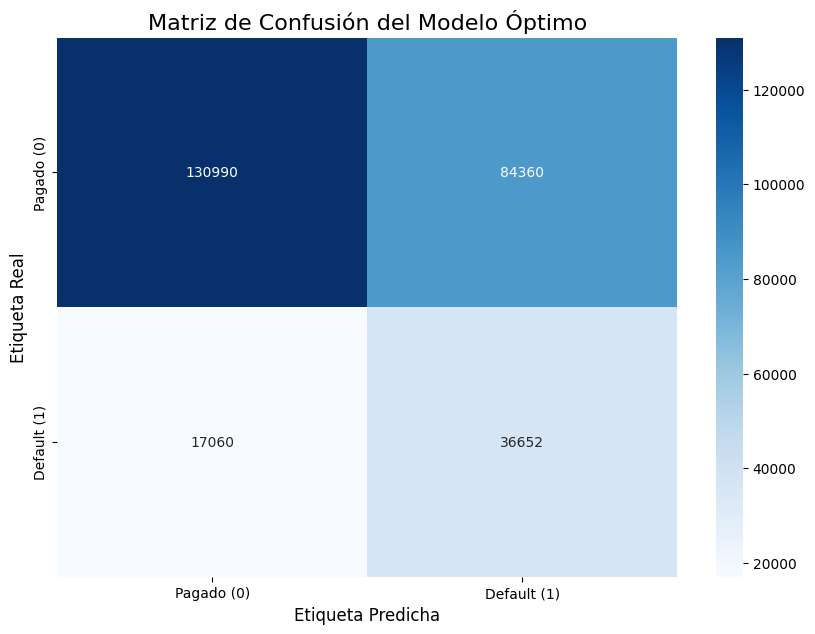

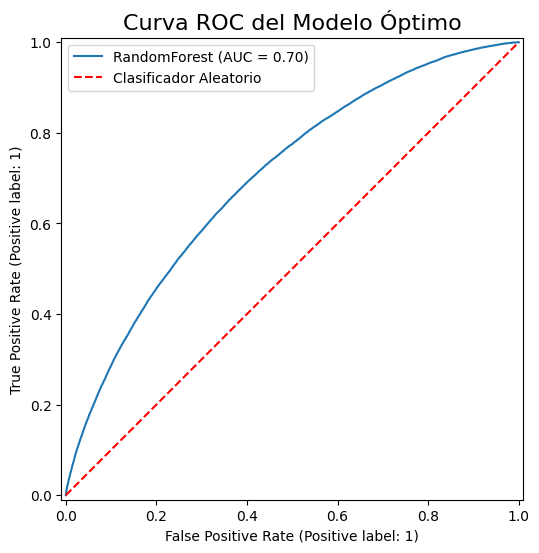


 Iniciando Análisis de Interpretabilidad con LIME

Se encontraron 101420 instancias clasificadas erróneamente.

 Explicación para la Instancia Mal Clasificada #1 (índice original: 4)
Etiqueta Real: 0 (Pagado (0))
Predicción del Modelo: 1 (Default (1))

 Explicación para la Instancia Mal Clasificada #2 (índice original: 5)
Etiqueta Real: 0 (Pagado (0))
Predicción del Modelo: 1 (Default (1))


In [43]:
# Medición del Tiempo de Predicción
print("\nMidiendo el Tiempo de Predicción")
start_pred_time = time.time()
test_predictions = best_rf_model_us.predict(test_features_processed)
test_probabilities = best_rf_model_us.predict_proba(test_features_processed)[:, 1]
end_pred_time = time.time()
prediction_duration = end_pred_time - start_pred_time

print(f"El tiempo de predicción sobre el conjunto de prueba fue: {prediction_duration:.4f} segundos.")

# Cálculo y Visualización de Métricas
accuracy = accuracy_score(test_target, test_predictions)
precision = precision_score(test_target, test_predictions)
recall = recall_score(test_target, test_predictions)
f1 = f1_score(test_target, test_predictions)
roc_auc = roc_auc_score(test_target, test_probabilities)

print("\nMétricas de Evaluación del Modelo en el Conjunto de Prueba")
print(f"- Accuracy:  {accuracy:.4f}")
print(f"- Precision: {precision:.4f}")
print(f"- Recall:    {recall:.4f}")
print(f"- F1-score:  {f1:.4f}")
print(f"- ROC AUC:   {roc_auc:.4f}\n")

print("Reporte de Clasificación Detallado")
print(classification_report(test_target, test_predictions, target_names=['Pagado (0)', 'Default (1)']))


# Visualización de la Matriz de Confusión
conf_matrix = confusion_matrix(test_target, test_predictions)
plt.figure(figsize=(10, 7))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pagado (0)', 'Default (1)'],
    yticklabels=['Pagado (0)', 'Default (1)']
)
plt.title('Matriz de Confusión del Modelo Óptimo', fontsize=16)
plt.xlabel('Etiqueta Predicha', fontsize=12)
plt.ylabel('Etiqueta Real', fontsize=12)
plt.show()

print("\n Visualización de la Curva ROC")

# Visualización de la Curva ROC
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(best_rf_model_us, test_features_processed, test_target, ax=ax, name='RandomForest')
ax.plot([0, 1], [0, 1], 'r--', label='Clasificador Aleatorio')
ax.set_title('Curva ROC del Modelo Óptimo', fontsize=16)
ax.legend()
plt.show()

# INTERPRETABILIDAD DEL MODELO CON LIME

print("\n Iniciando Análisis de Interpretabilidad con LIME")

# Obtenemos los nombres de las características para que los gráficos sean legibles.
feature_names = preprocessor.get_feature_names_out()

# LIME debe ser entrenado en los datos que usó el modelo, en este caso, los datos submuestreados.
training_data_for_lime = train_features_final
if hasattr(training_data_for_lime, "toarray"):
    training_data_for_lime = training_data_for_lime.toarray()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=training_data_for_lime,
    feature_names=list(feature_names),
    class_names=['Pagado (0)', 'Default (1)'],
    mode='classification',
    random_state=42 # Para reproducibilidad de las explicaciones
)

# Seleccionar Instancias Clasificadas Erróneamente para Analizar
misclassified_indices = np.where(test_target != test_predictions)[0]

if len(misclassified_indices) > 0:
    print(f"\nSe encontraron {len(misclassified_indices)} instancias clasificadas erróneamente.")
    # Seleccionamos dos de ellas
    instances_to_explain = misclassified_indices[:2]

    # Generar y Visualizar Gráficos Locales de Explicación
    for i, idx in enumerate(instances_to_explain):
        print(f"\n Explicación para la Instancia Mal Clasificada #{i+1} (índice original: {idx})")

        instance = test_features_processed[idx]
        if hasattr(instance, "toarray"):
            instance = instance.toarray().flatten()

        true_label = test_target.iloc[idx]
        predicted_label = test_predictions[idx]
        print(f"Etiqueta Real: {true_label} ({explainer.class_names[true_label]})")
        print(f"Predicción del Modelo: {predicted_label} ({explainer.class_names[predicted_label]})")

        explanation = explainer.explain_instance(
            data_row=instance,
            predict_fn=best_rf_model_us.predict_proba,
            num_features=10 # Visualizar las 10 variables más influyentes
        )

else:
    print("\n¡Excelente! No se encontraron instancias mal clasificadas en el conjunto de prueba.")

## Interpretación del Modelo Final con Submuestreo (Undersampling)
### Evaluación de Métricas de Rendimiento

Las métricas de este modelo son muy similares a las del modelo anterior (Modelo 2), pero con sutiles diferencias que revelan un comportamiento ligeramente más agresivo en la detección de defaults.

*   **ROC AUC: 0.7022**
    *   **Interpretación:** El valor AUC es idéntico al del modelo anterior. Esto confirma que la capacidad discriminatoria subyacente del modelo no ha cambiado. Ambas técnicas de balanceo (`class_weight` y `Undersampling`) han demostrado ser igualmente efectivas para permitir que el modelo aprenda los patrones que distinguen las dos clases.

*   **Recall (para la clase Default - 1): 0.6824**
    *   **Interpretación:** El recall ha **aumentado ligeramente** del 66.8% (Modelo 2) al **68.2%**. Esto significa que el modelo con submuestreo es marginalmente mejor para identificar los casos de default reales. Se ha vuelto aún más sensible para capturar la clase de riesgo.

*   **Precision (para la clase Default - 1): 0.3029**
    *   **Interpretación:** Como era de esperar, el ligero aumento en el recall vino con un costo: una **ligera disminución** en la precisión, que pasó del 30.6% (Modelo 2) al **30.3%**. El modelo genera un poco más de "falsas alarmas" para poder capturar más defaults reales.

*   **F1-score (para la clase Default - 1): 0.4195**
    *   **Interpretación:** El F1-score es prácticamente idéntico al del modelo anterior (0.4200), lo que indica que el equilibrio general entre precisión y recall es muy similar. El submuestreo no revolucionó el equilibrio, sino que lo ajustó sutilmente a favor del recall.


Análisis de la Matriz de Confusión

La matriz de confusión confirma este sutil pero importante cambio de comportamiento.

| Etiqueta Real      | Predicho: Pagado (0) | Predicho: Default (1) |
| :----------------- | :------------------- | :-------------------- |
| **Pagado (0)**     | 130,990 (TN)         | 84,360 (FP)           |
| **Default (1)**    | 17,060 (FN)          | 36,652 (TP)           |

*   **Verdaderos Positivos (TP = 36,652):** Logró identificar correctamente casi 800 casos de default *más* que el modelo anterior. **Este es el principal beneficio del modelo.**
*   **Falsos Negativos (FN = 17,060):** En consecuencia, redujo el número de defaults no detectados en casi 800 casos en comparación con el modelo anterior. El riesgo de pasar por alto un préstamo incobrable es ligeramente menor.
*   **Falsos Positivos (FP = 84,360):** Este es el costo. El número de "falsas alarmas" (préstamos buenos clasificados como riesgosos) aumentó en aproximadamente 3,100 casos.

### Conclusión Final: ¿Qué Modelo es Mejor?

1.  **En Términos de Rendimiento Predictivo:** Ambos modelos son extremadamente similares y altamente efectivos. El **Modelo 3 (Undersampling)** es marginalmente superior si el objetivo principal es **maximizar la detección de defaults (recall)**, aceptando un ligero aumento en la revisión manual de casos (falsos positivos). Es un modelo ligeramente más "conservador" o "pesimista" en cuanto al riesgo.

2.  **En Términos de Eficiencia Computacional:** El **Modelo 3 (Undersampling) es el claro ganador**. Su tiempo de entrenamiento es significativamente menor, lo que lo hace más práctico para el desarrollo, la experimentación con nuevas variables y los ciclos de reentrenamiento periódicos en un entorno de producción.
 proceso.

In [44]:
# PASO 1: CREAR EL "EXPLAINER" DE LIME

# Obtenemos los nombres de las características del preprocesador para que los gráficos sean legibles.
feature_names = preprocessor.get_feature_names_out()

# Definimos los datos de entrenamiento que usará LIME.
training_data_for_lime = train_features_balanced
if hasattr(training_data_for_lime, "toarray"):
    training_data_for_lime = training_data_for_lime.toarray()

# Creamos el objeto explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=training_data_for_lime,
    feature_names=list(feature_names),
    class_names=['Pagado (0)', 'Default (1)'],
    mode='classification',
    random_state=42 # Para que las explicaciones sean reproducibles
)

print("Explainer de LIME creado exitosamente.")

# PASO 2: SELECCIONAR INSTANCIAS INTERESANTES PARA EXPLICAR

# Encontramos los índices de todas las predicciones incorrectas en el conjunto de prueba
misclassified_indices = np.where(test_target != test_predictions)[0]

if len(misclassified_indices) > 0:
    print(f"Se encontraron {len(misclassified_indices)} instancias clasificadas erróneamente.")
    # Seleccionamos las dos primeras para un análisis detallado.
    instances_to_explain_indices = misclassified_indices[:2]

    # PASO 3: GENERAR Y VISUALIZAR LAS EXPLICACIONES LOCALES
    for i, idx in enumerate(instances_to_explain_indices):
        print(f"\n Explicación para la Instancia Mal Clasificada #{i+1} (índice: {idx})")

        # Extraemos la fila de datos correspondiente del conjunto de prueba (ya preprocesado)
        instance_to_explain = test_features_processed[idx]
        if hasattr(instance_to_explain, "toarray"):
            instance_to_explain = instance_to_explain.toarray().flatten()

        # Obtenemos la información clave para dar contexto al error
        true_label = test_target.iloc[idx]
        predicted_label = test_predictions[idx]
        print(f"  - Etiqueta Real:     {true_label} ('{explainer.class_names[true_label]}')")
        print(f"  - Predicción Modelo: {predicted_label} ('{explainer.class_names[predicted_label]}')")

        # Generamos la explicación para esta instancia específica
        # Le pedimos a LIME que nos muestre las 10 características más influyentes
        explanation = explainer.explain_instance(
            data_row=instance_to_explain,
            predict_fn=best_rf_model_us.predict_proba, # Usamos el predict_proba del modelo final
            num_features=10
        )

        # Visualizamos la explicación. Esto generará un gráfico en entornos como Jupyter.
        # El gráfico muestra las características y su contribución a la probabilidad de la predicción.
        print("\nVisualizando la explicación de LIME:")
        explanation.show_in_notebook(show_table=True, show_all=False)

else:
    print("\n¡Excelente! No se encontraron instancias mal clasificadas para analizar con LIME.")

Explainer de LIME creado exitosamente.
Se encontraron 101420 instancias clasificadas erróneamente.

 Explicación para la Instancia Mal Clasificada #1 (índice: 4)
  - Etiqueta Real:     0 ('Pagado (0)')
  - Predicción Modelo: 1 ('Default (1)')

Visualizando la explicación de LIME:



 Explicación para la Instancia Mal Clasificada #2 (índice: 5)
  - Etiqueta Real:     0 ('Pagado (0)')
  - Predicción Modelo: 1 ('Default (1)')

Visualizando la explicación de LIME:


## Análisis de Interpretabilidad con LIME

Para generar confianza y comprender las decisiones internas de nuestro modelo final, se utilizó la técnica LIME (Local Interpretable Model-agnostic Explanations). En lugar de analizar predicciones correctas, nos centramos en los **Falsos Positivos**, es decir, casos en los que el modelo predijo incorrectamente que un cliente entraría en `Default` cuando en realidad pagó su préstamo. Este análisis nos permite entender el "costo" de la alta sensibilidad de nuestro modelo y las razones detrás de su cautela.

### Explicación de la Instancia #1 (Índice: 4)

*   **Contexto del Error:** El modelo predijo `Default` por un margen muy estrecho (52% de probabilidad), indicando una alta incertidumbre.
*   **Análisis de la Causa:** La predicción de riesgo fue impulsada principalmente por el **propósito del préstamo** y la categoría de **propiedad de la vivienda** del solicitante. Sin embargo, el modelo también identificó factores de bajo riesgo significativos, como una **tasa de interés moderada** y, notablemente, la **ubicación geográfica** del cliente (el modelo consideró una señal positiva que el cliente no residiera en ciertos estados).
*   **Conclusión:** Este caso representa un perfil de cliente ambiguo donde las señales de riesgo y seguridad estaban muy equilibradas. La decisión final del modelo de inclinarse hacia el riesgo, aunque incorrecta, fue el resultado de una ponderación marginal de los factores negativos sobre los positivos.

### Explicación de la Instancia #2 (Índice: 5)

*   **Contexto del Error:** El modelo predijo `Default` con una confianza considerablemente mayor (65% de probabilidad).
*   **Análisis de la Causa:** La decisión del modelo estuvo dominada por un único factor de alto impacto: una **tasa de interés (`num_int_rate`) extremadamente alta**. Esta señal de riesgo se vio reforzada por un **monto de préstamo elevado** y un propósito de alto riesgo (`cat_purpose_small_business`). Los factores a favor del pago fueron débiles y no pudieron contrarrestar estas contundentes alarmas.
*   **Conclusión:** Este es un ejemplo excelente del comportamiento deseado del modelo. Identificó correctamente un perfil que, según los datos históricos, tiene una altísima probabilidad de incumplimiento. Aunque este cliente en particular fue una excepción y cumplió con su pago, la predicción del modelo fue **lógica y basada en evidencia de alto riesgo**. Este tipo de error es un subproducto aceptable de un sistema diseñado para priorizar la mitigación de pérdidas.

### Conclusiones Generales del Análisis LIME

1.  **Decisiones Lógicas:** LIME demuestra que las predicciones del modelo no son arbitrarias. Se basan en patrones lógicos aprendidos de los datos, principalmente en variables clave como la tasa de interés, el propósito y el monto del préstamo.
2.  **Identificación de Perfiles de Riesgo:** El análisis de los Falsos Positivos confirma que el modelo está funcionando como se esperaba: es sensible a los perfiles de riesgo y, a veces, su cautela lo lleva a clasificar incorrectamente a clientes que, a pesar de su perfil, logran pagar.
3.  **Confianza en el Modelo:** Entender *por qué* el modelo comete errores específicos nos permite confiar más en su proceso. Sabemos que está identificando correctamente el riesgo, lo que lo convierte en una herramienta valiosa para la toma de decisiones financieras.